# Modelos Preditivos

## Métricas de Avaliação

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

In [ ]:
X, y = make_classification(
    n_samples=3000, n_features=20,
    n_informative=6, n_redundant=2,
    class_sep=1.2, weights=[0.7, 0.3],
    random_state=42
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Modelo
clf = LogisticRegression(max_iter=1000, solver ="lbfgs")
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Probabilidade da classe positiva
y_score = clf.predict_proba(X_test)[:, 1]

In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

In [ ]:
#Métricas
y_pred =(y_score > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred) # matriz de confusão
acc = accuracy_score(y_test, y_pred) # acuracia
prec = precision_score(y_test, y_pred) # precisão
rec = recall_score(y_test, y_pred) #recall
f1 = f1_score(y_test, y_pred) # f1-score

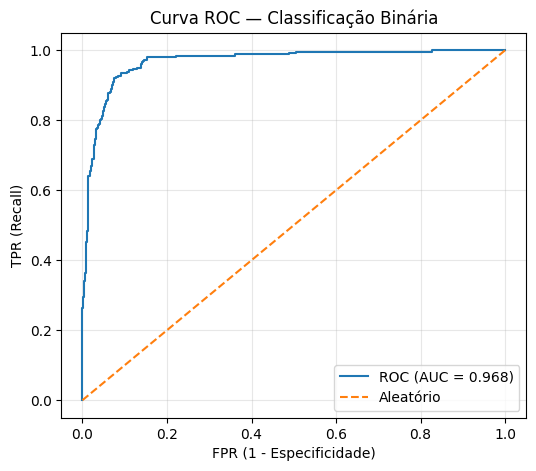

In [ ]:
# Visualização
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Aleatório')
plt.xlabel('FPR (1 - Especificidade)')
plt.ylabel('TPR (Recall)')
plt.title('Curva ROC — Classificação Binária')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.show()


In [ ]:
print(f"AUC-ROC: {auc:.3f}")
print("Matriz de confusão no limiar escolhido:")
print(cm)
print(f"Precisão: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")

AUC-ROC: 0.968
Matriz de confusão no limiar escolhido:
[[598  41]
 [ 32 229]]
Precisão: 0.848 | Recall: 0.877 | F1: 0.863


In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error)
from scipy.stats import pearsonr

In [ ]:
data = load_diabetes()
X, y = data.data,  data.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
#Modelo
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
pearson_corr,_ = pearsonr(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

In [ ]:
# Visualização

print(f"""
📊 Avaliação do Modelo (Regressão Linear):

🔸 R²: {r2:.2f}
    → Proporção da variância explicada pelo modelo (ideal: próximo de 1).

🔸 MAE: {mae:.2f}
    → Erro absoluto médio em unidades da variável dependente.

🔸 RMSE: {rmse:.2f}
    → Raiz do erro quadrático médio. Penaliza mais erros maiores.

🔸 Correlação de Pearson: {pearson_corr:.2f}
    → Correlação linear entre os valores preditos e observados.

🔸 MAPE: {mape:.2f}%
    → Erro percentual absoluto médio. Indica que o modelo erra cerca de {mape:.1f}% em média.
""")


📊 Avaliação do Modelo (Regressão Linear):

🔸 R²: 0.48
    → Proporção da variância explicada pelo modelo (ideal: próximo de 1).

🔸 MAE: 41.92
    → Erro absoluto médio em unidades da variável dependente.

🔸 RMSE: 53.12
    → Raiz do erro quadrático médio. Penaliza mais erros maiores.

🔸 Correlação de Pearson: 0.69
    → Correlação linear entre os valores preditos e observados.

🔸 MAPE: 36.67%
    → Erro percentual absoluto médio. Indica que o modelo erra cerca de 36.7% em média.



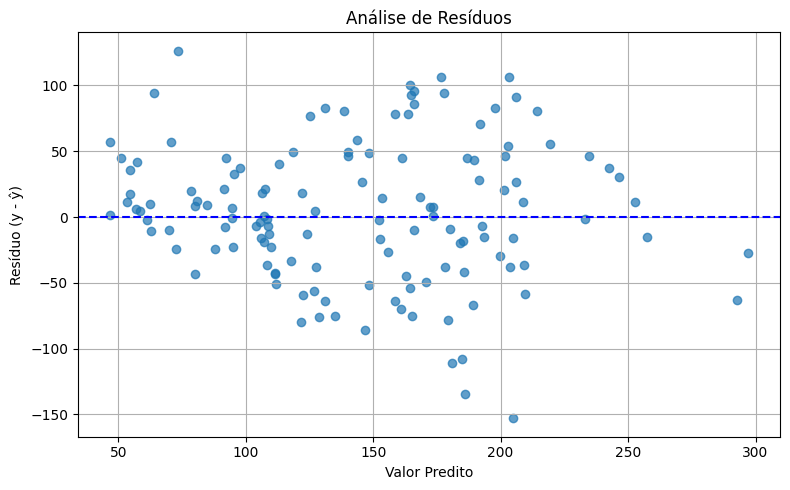

In [ ]:
# Visualização Residuos
plt.figure(figsize=(8, 5))
plt.scatter(y_pred,y_test - y_pred , alpha=0.7)
plt.axhline(0, color='blue', linestyle='--')
plt.xlabel("Valor Predito")
plt.ylabel("Resíduo (y - ŷ)")
plt.title("Análise de Resíduos")
plt.grid(True)
plt.tight_layout()

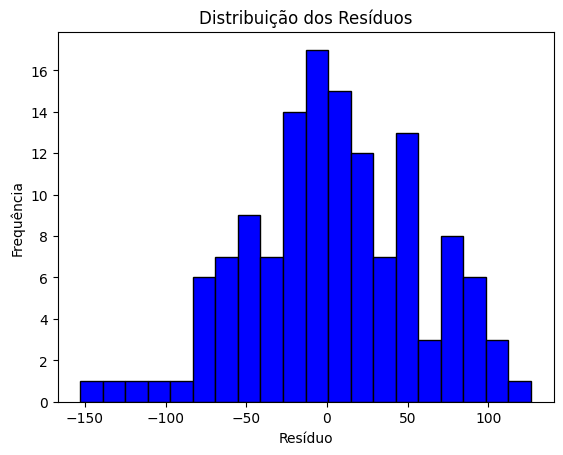

In [ ]:
# Visualização Histograma
plt.hist(y_test - y_pred, bins=20, color='blue', edgecolor='black')
plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.show()

## Métodos de Avaliação

In [ ]:
# Conjunto de validação (Holdout)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.datasets import fetch_california_housing

X, y = fetch_california_housing(return_X_y=True)

# Conjunto de validação (Holdout) (separar 20-30% para teste)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
r2 = r2_score(y_val, y_pred)
print(f"R² no conjunto de validação: {r2:.2f}")

R² no conjunto de validação: 0.60


In [ ]:
#Validação Cruzada
from sklearn.model_selection import cross_val_score

score = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"R² na validação cruzada: {score.mean():.2f}")

R² na validação cruzada: 0.55


In [ ]:
#Bootstrapping
from sklearn.utils import resample
import numpy as np

n_iterations = 100
scores = []

#booststapping
for _ in range(n_iterations):
    X_resampled, y_resampled = resample(X, y, replace=True, random_state=None)
    model = LinearRegression()
    model.fit(X_resampled, y_resampled)

    # Avaliar no conjunto original
    y_pred = model.predict(X)
    score = r2_score(y, y_pred)
    scores.append(score)

print(f"Bootstrap R² - Média: {np.mean(scores):.3f}")
print(f"Bootstrap R² - Desvio padrão: {np.std(scores):.3f}")

Bootstrap R² - Média: 0.571
Bootstrap R² - Desvio padrão: 0.199


## Curva de Aprendizado

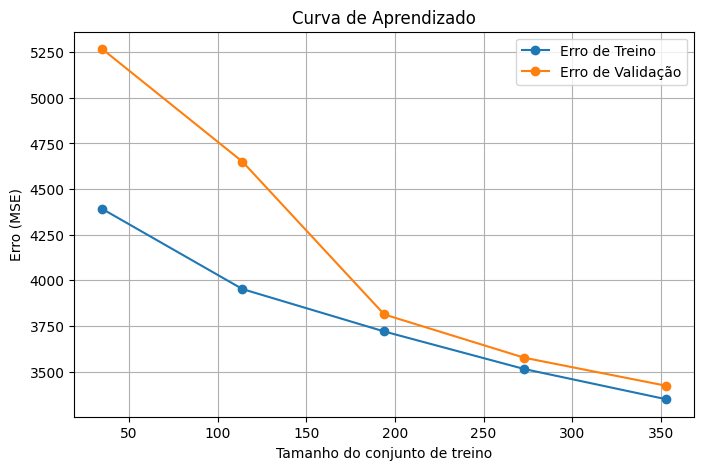

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge
from sklearn.datasets import load_diabetes
from sklearn.model_selection import ShuffleSplit
import matplotlib.pyplot as plt
import numpy as np

X, y = load_diabetes(return_X_y=True)

train_sizes, train_scores, test_scores = learning_curve(
    Ridge(), X, y, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42)

train_scores_mean = -train_scores.mean(axis=1)
test_scores_mean = -test_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Erro de Treino")
plt.plot(train_sizes, test_scores_mean, 'o-', label="Erro de Validação")
plt.xlabel("Tamanho do conjunto de treino")
plt.ylabel("Erro (MSE)")
plt.title("Curva de Aprendizado")
plt.legend(loc="best")
plt.grid()
plt.show()

# Modelos Descritivos

## Critérios Internos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [ ]:
X, y = make_blobs(n_samples=500, centers=4, cluster_std=0.6, random_state=42)

In [ ]:
#modelo
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

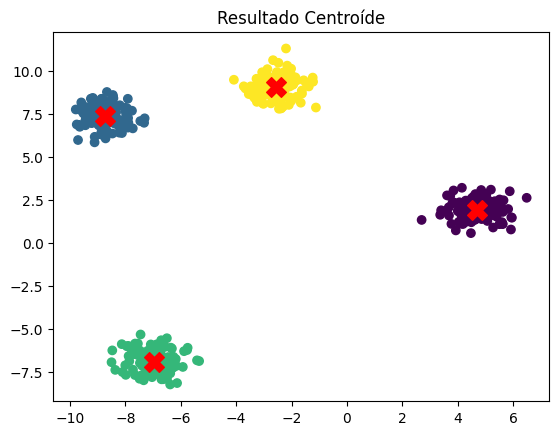

In [ ]:
#Visualização
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X')
plt.title("Resultado Centroíde")
plt.show()

In [ ]:
# Índice de Silhueta
silhouette = silhouette_score(X, labels)
print(f"Índice de Silhueta: {silhouette:.2f}") # Valores próximos de 1: boas separação dos clusters

Índice de Silhueta: 0.88


In [ ]:
# Índice de Calinski-Harabasz
ch = calinski_harabasz_score(X, labels)
print(f"Índice de Calinski-Harabasz: {ch:.2f}") # Valores maiores: melhor clusterização

Índice de Calinski-Harabasz: 15874.71


In [ ]:
# Índice de Davies-Bouldin
db = davies_bouldin_score(X, labels)
print(f"Índice de Davies-Bouldin: {db:.2f}") # Valores menores: melhor clusterização

Índice de Davies-Bouldin: 0.17


## Critérios Externos

In [ ]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, adjusted_mutual_info_score
from sklearn.preprocessing import StandardScaler

In [ ]:
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y_true = data.target

In [ ]:
# Normalização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Modelo
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

In [ ]:
# Métrica
ari = adjusted_rand_score(y_true, labels)
fmi = fowlkes_mallows_score(y_true, labels)
ami = adjusted_mutual_info_score(y_true, labels)

In [ ]:
# Visualização

results_df = pd.DataFrame({
    'Metric': ['Adjusted Rand Index (ARI)', 'Fowlkes-Mallows Index (FMI)', 'Adjusted Mutual Information (AMI)'],
    'Score': [ari, fmi, ami]
})

results_df

,Metric,Score
0,Adjusted Rand Index (ARI),0.897495
1,Fowlkes-Mallows Index (FMI),0.931908
2,Adjusted Mutual Information (AMI),0.874579


# Modelos Prescritivos

## Critérios Internos

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
# Ótimização é um problema onde você quer minimizar ou maximizar uma função objetivo
# Função objetivo (Rastrigin)

def rastrigin(x, A=10):
    x = np.asarray(x)
    n = len(x)
    return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))


In [ ]:
# Custo Total

# Gera uma solução com 5 variáveis (entre -5.12 e 5.12)
solucao = np.random.uniform(-5.12, 5.12, size=5)
custo = rastrigin(solucao)

print("Solução:", solucao)
print("Custo:", custo)

Solução: [ 3.6020567  -2.85336589  4.98826774 -0.18632229 -2.85283764]
Custo: 86.24955213983225


In [ ]:
# Tempo de Execução
import time

inicio = time.time()

# Simulando a busca pela melhor solução entre 1000 aleatórias
melhor = None
melhor_custo = float('inf')

for _ in range(1000):
    s = np.random.uniform(-5.12, 5.12, size=5)
    c = rastrigin(s)
    if c < melhor_custo:
        melhor = s
        melhor_custo = c

fim = time.time()
print(f"Melhor custo encontrado: {melhor_custo:.4f}")
print(f"Tempo de execução: {fim - inicio:.4f} segundos")


Melhor custo encontrado: 22.2714
Tempo de execução: 0.0349 segundos


In [ ]:
# Número de Iterações

iteracoes = 0

for _ in range(1000):
    iteracoes += 1
    s = np.random.uniform(-5.12, 5.12, size=5)
    c = rastrigin(s)
    if c < melhor_custo:
        melhor = s
        melhor_custo = c

print("Número de iterações:", iteracoes)

Número de iterações: 1000


In [ ]:
# Estabilidade
resultados = []

for i in range(20):  # 20 execuções
    melhores = [rastrigin(np.random.uniform(-5.12, 5.12, 5)) for _ in range(1000)]
    resultados.append(min(melhores))

media = np.mean(resultados)
desvio = np.std(resultados)

print(f"Média dos melhores custos: {media:.4f}")
print(f"Desvio padrão (estabilidade): {desvio:.4f}")


Média dos melhores custos: 25.4448
Desvio padrão (estabilidade): 4.6923


## Critérios Externos

In [ ]:
import numpy as np
from scipy.optimize import minimize
from statistics import mean, stdev

# Função objetivo
def func_objetivo(x):
    return (x[0] - 3)**2 + (x[1] + 1)**2 + np.sin(3*x[0]) + np.cos(2*x[1])

def solucao_otima_aproximada():
    best = float('inf')
    for x in np.linspace(-5, 5, 100):
        for y in np.linspace(-5, 5, 100):
            val = func_objetivo([x, y])
            if val < best:
                best = val
    return best

sol_otima = solucao_otima_aproximada()

custos = []
for i in range(20):
    x0 = np.random.uniform(-5, 5, size=2)
    result = minimize(func_objetivo, x0, method='Nelder-Mead')
    custos.append(result.fun)

# Avaliação dos critérios
media_custo = mean(custos)
desvio_custo = stdev(custos)
gap = abs(media_custo - sol_otima) / abs(sol_otima)

print(f"Custo real operacional (média das execuções): {media_custo:.4f}")
print(f"Robustez da solução (desvio padrão): {desvio_custo:.4f}")
print(f"GAP médio para a solução ótima: {gap:.4%}")



Custo real operacional (média das execuções): -1.1641
Robustez da solução (desvio padrão): 0.5301
GAP médio para a solução ótima: 17.5431%
